<a href="https://colab.research.google.com/github/hamidb201214-svg/Lectures/blob/main/Statistics_Lecture4_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Chapter 4 statistics notebook using `Startupsin2020.csv`

This notebook uses the unicorn startup dataset to give **one practical example for each item** in the 4 sections below:

1. **Measure of Centrality**
   - Median
   - Mean
   - Mode

2. **Measure of Variability**
   - Range
   - Variance
   - Standard Deviation (SD)
   - Coefficient of Variation (CV)

3. **Relative Standing**
   - Percentile
   - Interquartile Range (IQR)

4. **Linear Relationship**
   - Covariance
   - Correlation Coefficient (CC or \(\rho\))
   - Coefficient of Determination (CD or \(r^2\))
   - Least Squares Method

**Dataset source**  
`https://raw.githubusercontent.com/hamidb201214-svg/Lectures/refs/heads/main/Startupsin2020.csv`


In [ ]:
data

,Company,Valuation ($B),Date Joined,Country,City,Industry,Select Investors
0,Bytedance,140,4/7/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,100,12/1/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,Stripe,95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG"
3,Klarna,45,12/12/2011,Sweden,Stockholm,Fintech,"Institutional Venture Partners, Sequoia Capita..."
4,Canva,40,1/8/2018,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat..."
...,...,...,...,...,...,...,...
931,YipitData,1,12/6/2021,United States,New York,Internet software & services,"RRE Ventures+, Highland Capital Partners, The ..."
932,Anyscale,1,12/7/2021,United States,Berkeley,Artificial Intelligence,"Andreessen Horowitz, Intel Capital, Foundation..."
933,Iodine Software,1,12/1/2021,United States,Austin,Data management & analytics,"Advent International, Bain Capital Ventures, S..."
934,ReliaQuest,1,12/1/2021,United States,Tampa,Cybersecurity,"KKR, FTV Capital, Ten Eleven Ventures"


## 1) Measure of Centrality

np.float64(3.051282051282051)

,Valuation ($B)
0,1


In [ ]:
data['Valuation ($B)'].median()

1.0


### Example interpretation
- **Mean** gives the average unicorn valuation.
- **Median** gives the middle valuation and is less affected by extreme firms like ByteDance or SpaceX.
- **Mode** gives the most common valuation in the dataset.


## 2) Measure of Variability

139

55.926779103249864

7.47842089636909

In [ ]:
7.47842089636909 * 7.47842089636909

55.926779103249864

In [ ]:
# coefficient of variation = ratio * 100


np.float64(245.0911050070542)

<Axes: xlabel='Variance', ylabel='Coefficient Variance'>

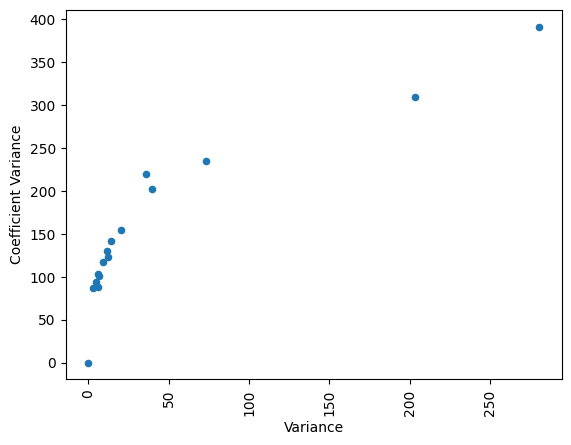

In [ ]:
summary = data.groupby("Industry")["Valuation ($B)"].mean().reset_index()
summary['Variance'] = data.groupby("Industry")["Valuation ($B)"].var().values
summary['Coefficient Variance'] = (data.groupby("Industry")["Valuation ($B)"].std()/data.groupby("Industry")["Valuation ($B)"].mean() * 100).values
summary.plot.scatter(x='Variance', y='Coefficient Variance', rot=90)

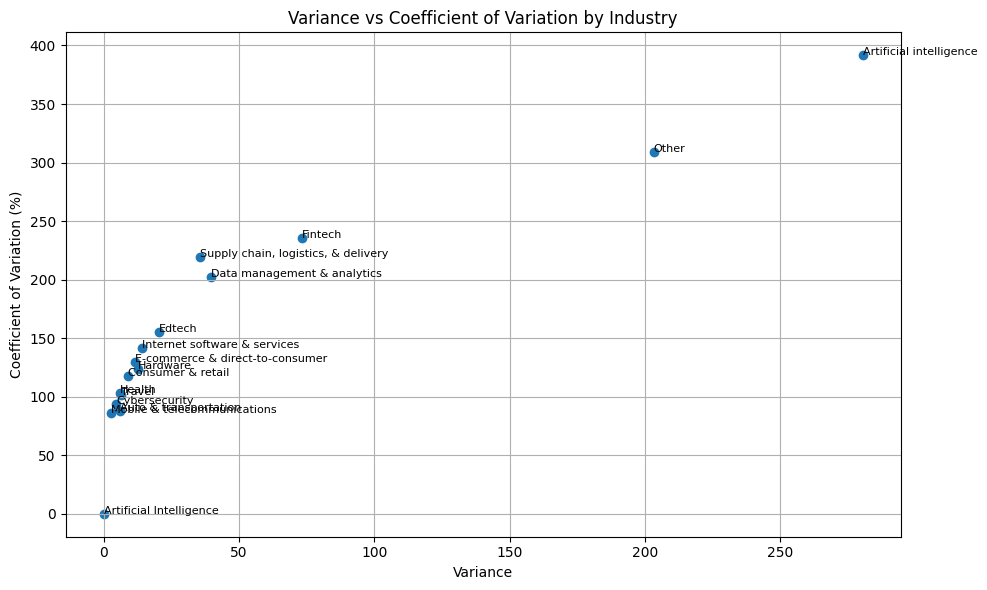

In [ ]:
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 3) Simple plot: Variance vs CV
# ----------------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(summary["Variance"], summary["Coefficient Variance"])

for _, row in summary.iterrows():
    plt.text(row["Variance"], row["Coefficient Variance"], row["Industry"], fontsize=8)

plt.xlabel("Variance")
plt.ylabel("Coefficient of Variation (%)")
plt.title("Variance vs Coefficient of Variation by Industry")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Coefficient of variation is important because it measures relative variability, allowing fair comparison across industries with different average valuations



,count,mean,std,min,25%,50%,75%,max
Industry,,,,,,,,
"Supply chain, logistics, & delivery",51.0,2.725490,5.976884,1.0,1.0,1.0,2.0,39.0
Data management & analytics,36.0,3.111111,6.296383,1.0,1.0,1.0,3.0,38.0


In [ ]:
# Coefficient of variation is important because it measures relative variability, allowing fair comparison across industries with different average valuations


,count,mean,std,min,25%,50%,75%,max
Industry,,,,,,,,
Auto & transportation,29.0,2.758621,2.429803,1.0,1.0,2.0,3.0,11.0
Cybersecurity,41.0,2.317073,2.173005,1.0,1.0,1.0,2.0,9.0



### Example interpretation
- **Range** shows the overall spread from the smallest to largest valuation.
- **Variance** measures average squared spread around the mean.
- **Standard deviation** puts that spread back in the original unit: **billions of dollars**.
- **CV** shows relative variability, useful because it compares spread to the mean itself.


## 3) Relative Standing

np.float64(6.0)

np.float64(2.0)

<Axes: >

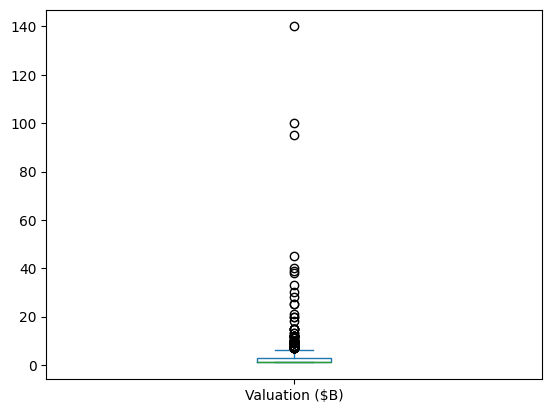

### Bonus: Canva’s Valuation Ranking

In [ ]:
threshold = data[data["Company"] == "Canva"]['Valuation ($B)'].iloc[0]

In [ ]:
(data['Valuation ($B)'] <= threshold).mean() * 100

np.float64(99.57264957264957)


### Example interpretation
- The **90th percentile** is the valuation level that about 90% of startups fall below.
- **IQR** measures the spread of the middle 50% of valuations and is less sensitive to outliers than the range.

- **Canva's percentile rank** tells us how its valuation compares with the rest of the dataset.


## 4) Linear Relationship


For the linear relationship section, we use:

- **X = Year Joined**
- **Y = Valuation ($B)**

This lets us examine whether more recently joined startups tend to have higher or lower valuations.


In [ ]:
import pandas as pd
import numpy as np

# Load the real Credit Card Default dataset directly from the public ISLR repository
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/ISLR/Default.csv"


In [ ]:
df

,rownames,default,student,balance,income
0,1,No,No,729.526495,44361.625074
1,2,No,Yes,817.180407,12106.134700
2,3,No,No,1073.549164,31767.138947
3,4,No,No,529.250605,35704.493935
4,5,No,No,785.655883,38463.495879
...,...,...,...,...,...
9995,9996,No,No,711.555020,52992.378914
9996,9997,No,No,757.962918,19660.721768
9997,9998,No,No,845.411989,58636.156984
9998,9999,No,No,1569.009053,36669.112365


In [ ]:
df['balance'].cov(df['income']) # May be difficulte to juge

np.float64(-982142.3355404867)

In [ ]:
# Correlation shows the strength and direction of a linear relationship:
# values near 1 = strong positive, near -1 = strong negative, near 0 = weak/no linear relationship.
# A drawback is that it does not capture non-linear relationships and does not imply causation.


np.float64(-0.1522434005860668)

In [ ]:
# r^2: indicates how much of the linear variation is shared between balance and income.


np.float64(0.023178053022009606)

### Least squares line method

To fit the regression line of **balance** on **income**, we use:

$
\hat{y} = a + bx
$

where

$
b = \frac{\text{Cov}(x,y)}{\text{Var}(x)}
\qquad\text{and}\qquad
a = \bar{y} - b\bar{x}
$

- \(x\) = `income`
- \(y\) = `balance`
- \(b\) = slope
- \(a\) = intercept

In [ ]:
# Least squares slope and intercept


Slope (b) = -0.005522
Intercept (a) = 1020.449353
Least squares line: y_hat = 1020.449353 + -0.005522x


In [ ]:
# Predicted balance values from the least squares line
df['balance_hat'] = a + b * df['income']
df[['income', 'balance', 'balance_hat']].head()

,income,balance,balance_hat
0,44361.625074,729.526495,775.492806
1,12106.134700,817.180407,953.601555
2,31767.138947,1073.549164,845.037189
3,35704.493935,529.250605,823.295856
4,38463.495879,785.655883,808.061166


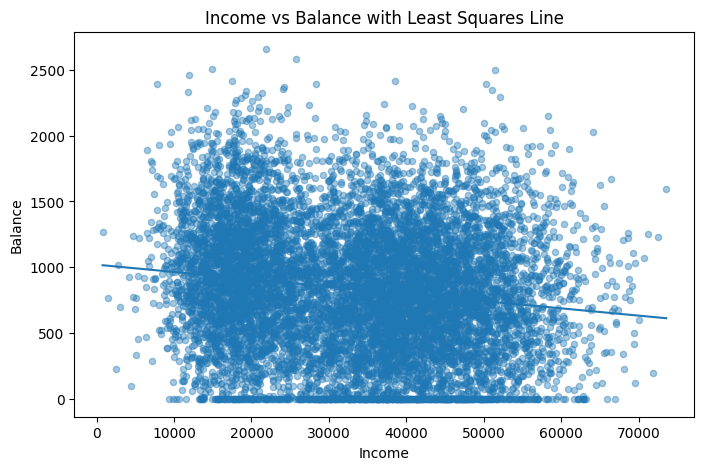

In [ ]:
# Scatter plot with least squares regression line
ax = df.plot.scatter(
    x='income',
    y='balance',
    figsize=(8, 5),
    title='Income vs Balance with Least Squares Line'
)

ax.plot(df['income'], a + b * df['income'])


In [ ]:
df

,rownames,default,student,balance,income,balance_hat
0,1,No,No,729.526495,44361.625074,775.492806
1,2,No,Yes,817.180407,12106.134700,953.601555
2,3,No,No,1073.549164,31767.138947,845.037189
3,4,No,No,529.250605,35704.493935,823.295856
4,5,No,No,785.655883,38463.495879,808.061166
...,...,...,...,...,...,...
9995,9996,No,No,711.555020,52992.378914,727.835408
9996,9997,No,No,757.962918,19660.721768,911.886547
9997,9998,No,No,845.411989,58636.156984,696.671527
9998,9999,No,No,1569.009053,36669.112365,817.969414


### Example interpretation
- **Covariance** shows whether the variables move together in the same or opposite direction.
- **Correlation coefficient (r)** standardizes the relationship to a value between -1 and 1.
- **Coefficient of determination (r²)** tells us the proportion of variation in one variable explained by the other in a linear model.
- **Least squares method** gives the best-fitting straight line for prediction.
- In the regression line **ŷ = a + bx**, **b** is the slope and **a** is the intercept.